In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from joblib import Parallel, delayed
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

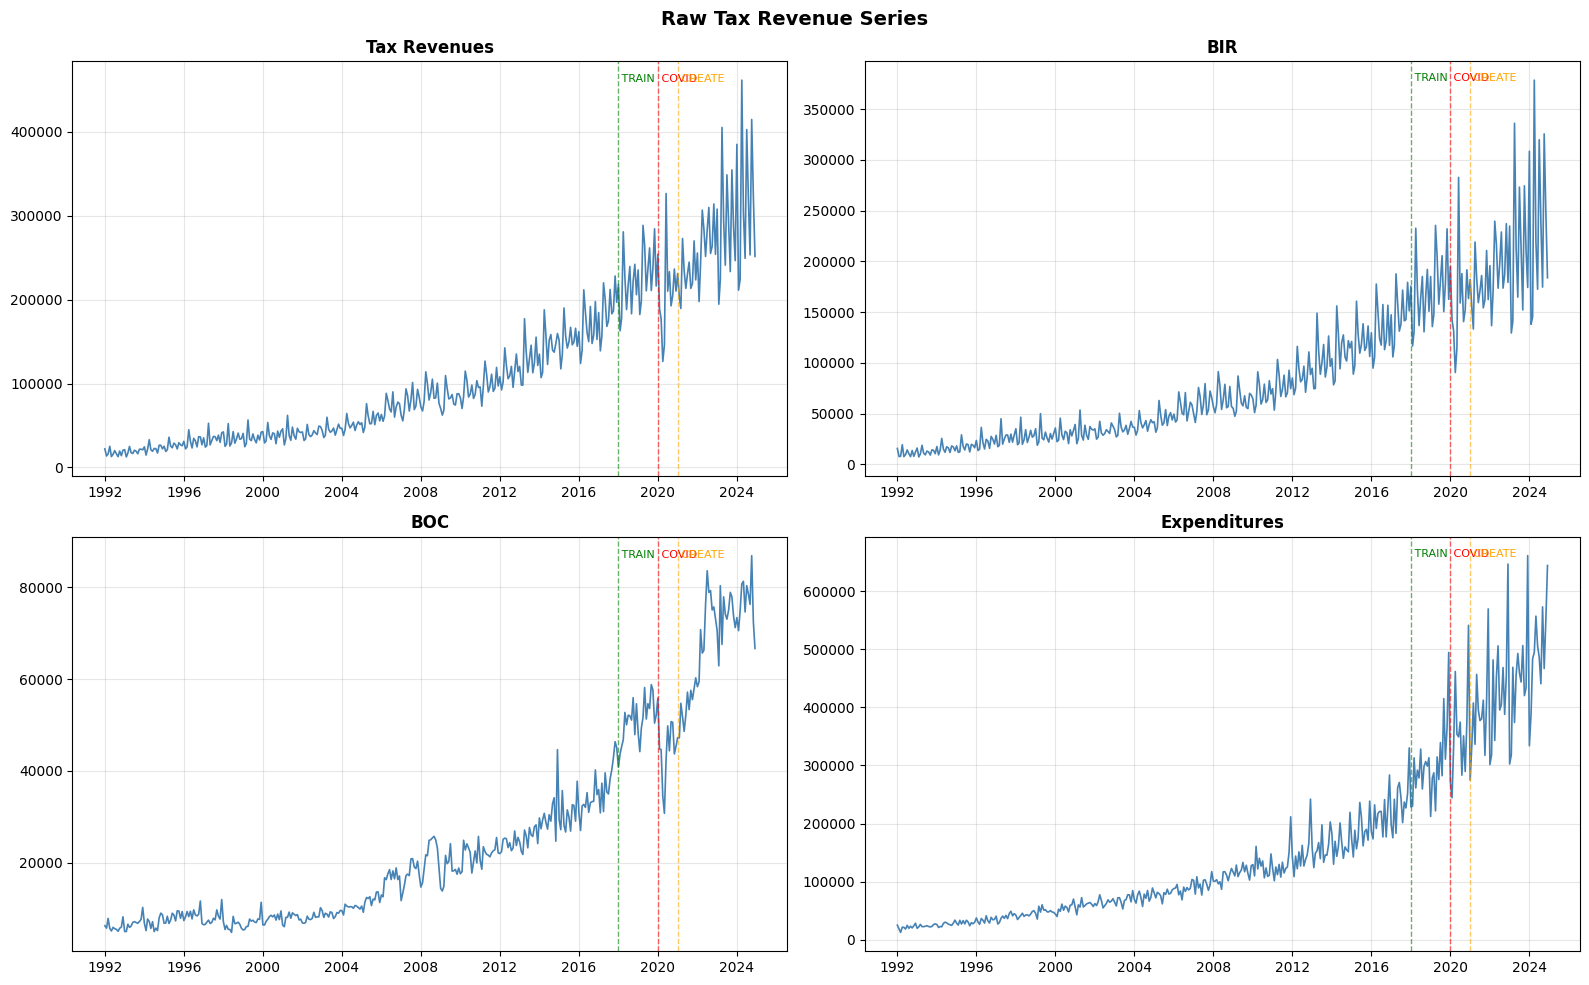

In [2]:
BREAK_LABELS = ['Tax Revenues', 'BIR', 'BOC', 'Expenditures']

# Load data — adjust filename/column as needed
df = pd.read_csv('Data/cordata.csv', parse_dates=['Date'], index_col='Date')
disagg = pd.read_csv('Data/disaggregated.csv')
disagg = disagg.rename(columns={'Unnamed: 3': 'Date'}).set_index('Date')
disagg.index = pd.to_datetime(disagg.index)

df = df.join(disagg, how='inner').sort_index()
df = df.loc['1992':]

raw_series = {}
for label in BREAK_LABELS:
    raw_series[label] = {
        'values': df[label].values,
        'dates':  df.index,
    }

# %% [markdown]
# ## Step 1: Plot Raw Series

# %%
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, label in zip(axes.flatten(), BREAK_LABELS):
    ax.plot(raw_series[label]['dates'], raw_series[label]['values'],
            linewidth=1.2, color='steelblue')
    for year, name, color in [(2018, 'TRAIN', 'green'), (2020, 'COVID', 'red'),
                               (2021, 'CREATE', 'orange')]:
        ax.axvline(pd.Timestamp(f'{year}-01-01'), color=color,
                   linestyle='--', alpha=0.6, linewidth=1)
        ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1] * 0.95,
                f' {name}', fontsize=8, color=color)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
fig.suptitle('Raw Tax Revenue Series', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
features = df[['BIR', 'BOC',  'TotalTrade_PHPMN',
               'NominalGDP_disagg', 'Inflation', 'USDPHP']].copy()

pct_cols = [ 'BIR', 'BOC',
            'TotalTrade_PHPMN', 'NominalGDP_disagg', 'USDPHP']
features_pct = features[pct_cols].pct_change(12)*100

inflation_diff = features[['Inflation']].diff(12)

features_growth = pd.concat([features_pct, inflation_diff], axis=1).dropna()

scaler = StandardScaler()
X = scaler.fit_transform(features_growth)

bics = []
for k in range(2, 7):
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                           n_init=10, random_state=42)
    gmm.fit(X)
    bics.append((k, gmm.bic(X)))
    print(f"  k={k}: BIC={gmm.bic(X):.0f}")

best_k = min(bics, key=lambda x: x[1])[0]

gmm = GaussianMixture(n_components=3, covariance_type='full',
                      init_params='random', n_init=10, random_state=42)
gmm.fit(X)
labels = gmm.predict(X)
probs = gmm.predict_proba(X)

  k=2: BIC=5915
  k=3: BIC=5909
  k=4: BIC=5935
  k=5: BIC=5955
  k=6: BIC=5940


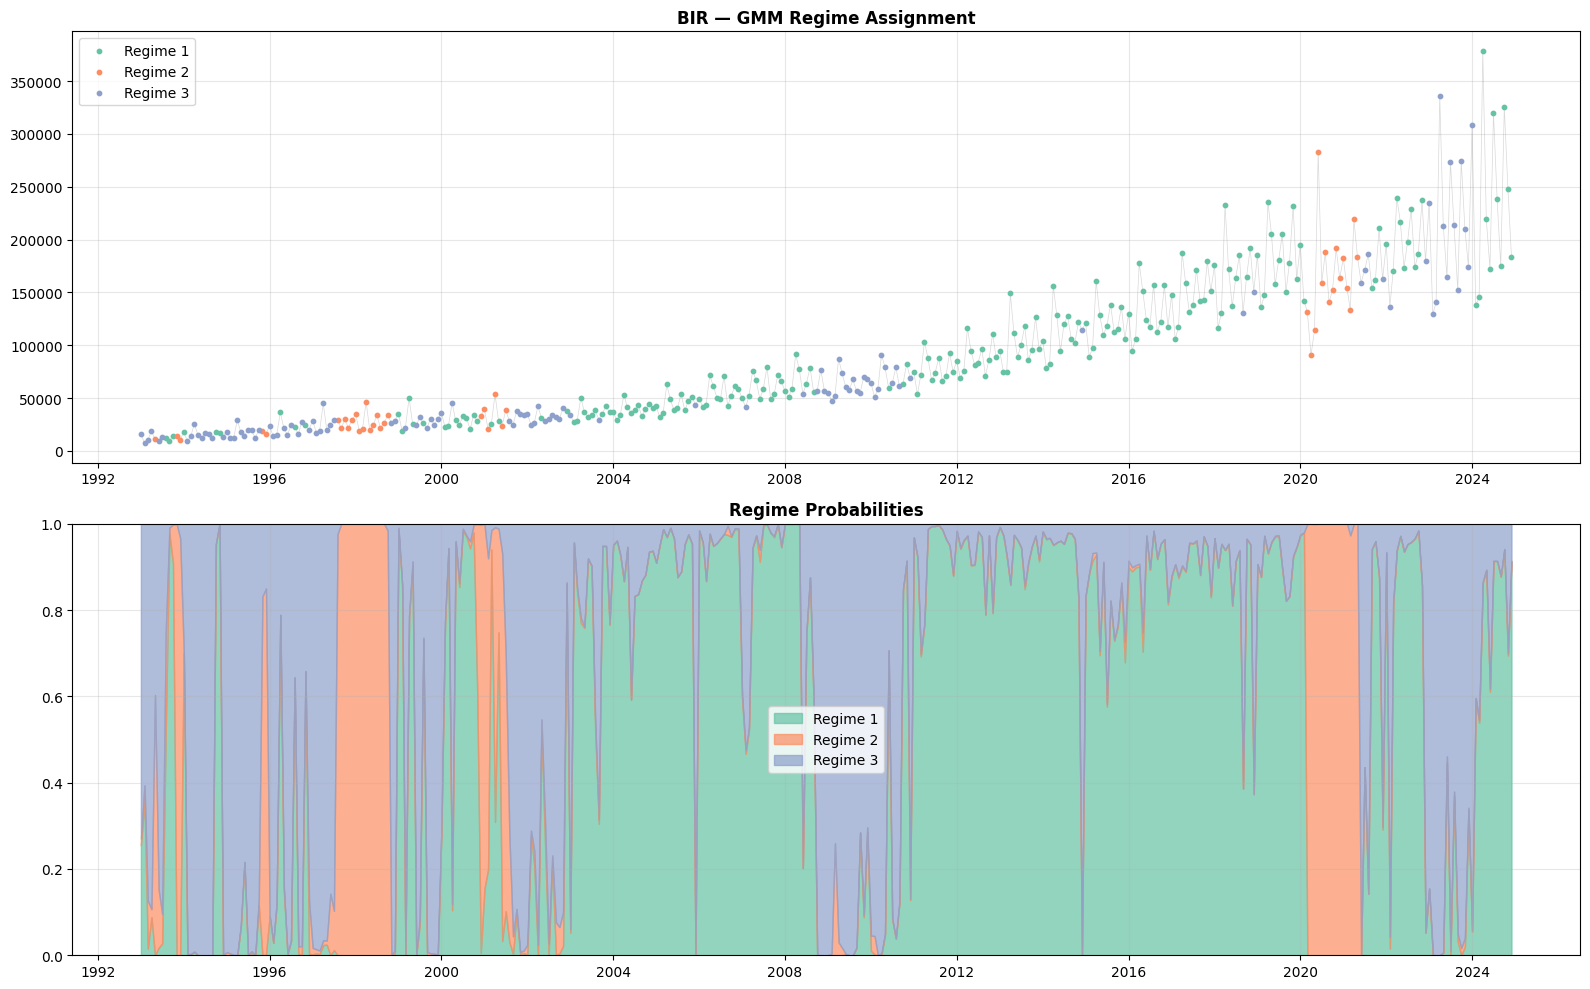


  GMM REGIME CHARACTERISTICS

  Regime 1 (225 months, 58.6%):
    BIR                      : mean=   12.4%, std=   7.7%
    BOC                      : mean=   14.4%, std=  15.3%
    TotalTrade_PHPMN         : mean=    9.2%, std=  12.0%
    NominalGDP_disagg        : mean=    9.5%, std=   2.4%
    USDPHP                   : mean=    1.2%, std=   7.0%
    Inflation                : mean=    0.1%, std=   2.5%

  Regime 2 (41 months, 10.7%):
    BIR                      : mean=   11.5%, std=  34.5%
    BOC                      : mean=   -2.8%, std=  25.0%
    TotalTrade_PHPMN         : mean=   22.4%, std=  33.4%
    NominalGDP_disagg        : mean=    3.6%, std=   9.4%
    USDPHP                   : mean=   17.4%, std=  21.6%
    Inflation                : mean=    0.9%, std=   2.3%

  Regime 3 (118 months, 30.7%):
    BIR                      : mean=    8.6%, std=  17.3%
    BOC                      : mean=    6.4%, std=  24.3%
    TotalTrade_PHPMN         : mean=   10.3%, std=  17.1%
  

In [12]:
regime_dates = features_growth.index

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
regime_colors = ['#66c2a5', '#fc8d62', '#8da0cb']
regime_names = [f'Regime {i+1}' for i in range(3)]

# Top: Tax Revenues colored by regime
ax = axes[0]
y = df.loc[regime_dates, 'BIR']
for j in range(3):
    mask = labels == j
    ax.scatter(regime_dates[mask], y.values[mask], c=regime_colors[j],
               s=10, label=regime_names[j], zorder=3)
ax.plot(regime_dates, y.values, color='gray', linewidth=0.5, alpha=0.3)
ax.set_title('BIR — GMM Regime Assignment', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom: Regime probabilities
ax2 = axes[1]
bottom = np.zeros(len(regime_dates))
for j in range(3):
    ax2.fill_between(regime_dates, bottom, bottom + probs[:, j],
                     alpha=0.7, color=regime_colors[j], label=regime_names[j])
    bottom += probs[:, j]
ax2.set_ylim(0, 1)
ax2.set_title('Regime Probabilities', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print regime characteristics
print(f"\n{'='*60}")
print(f"  GMM REGIME CHARACTERISTICS")
print(f"{'='*60}")
for j in range(3):
    mask = labels == j
    print(f"\n  Regime {j+1} ({mask.sum()} months, {mask.mean():.1%}):")
    for col in features_growth.columns:
        vals = features_growth.loc[mask, col]
        print(f"    {col:25s}: mean={vals.mean():7.1f}%, std={vals.std():6.1f}%")

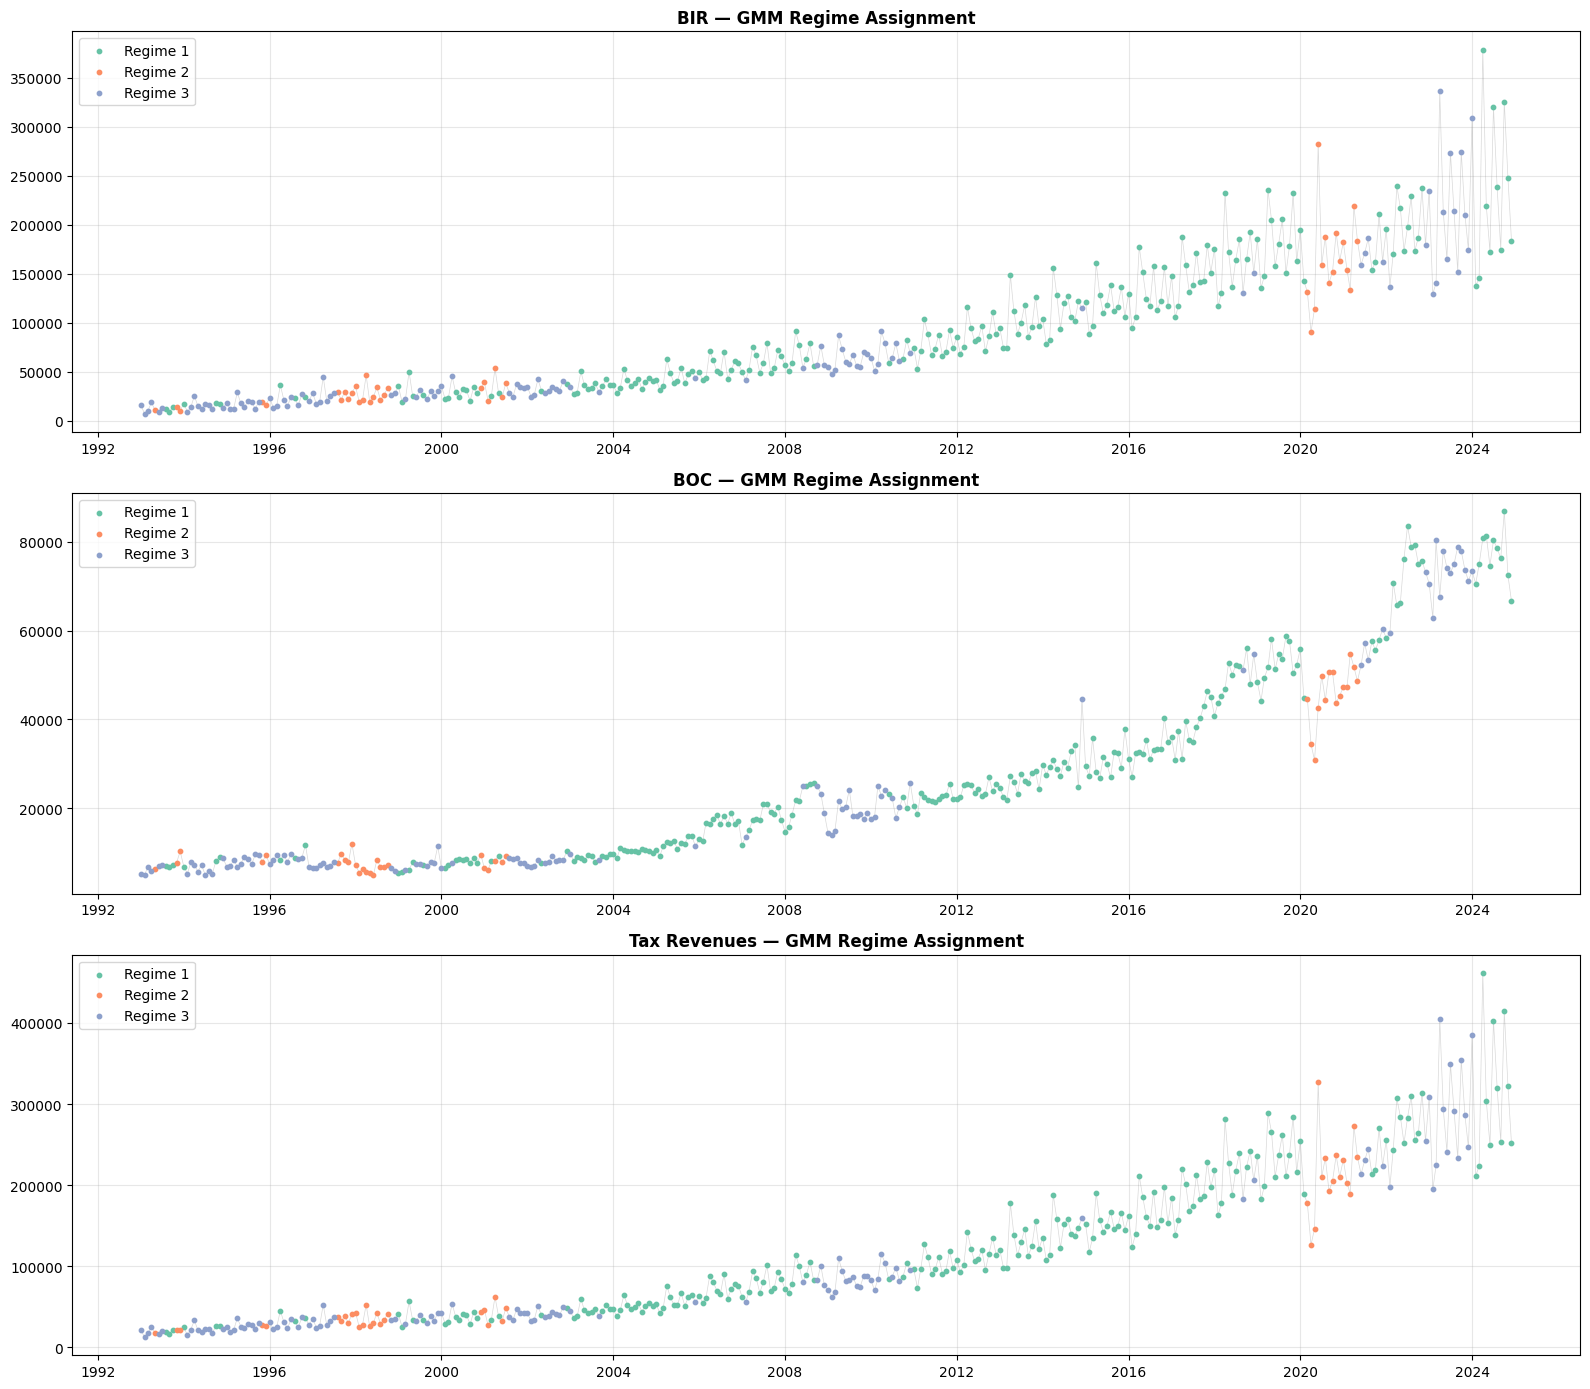

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
regime_colors = ['#66c2a5', '#fc8d62', '#8da0cb']

for ax, col in zip(axes, ['BIR', 'BOC', 'Tax Revenues']):
    y = df.loc[regime_dates, col]
    for j in range(3):
        mask = labels == j
        ax.scatter(regime_dates[mask], y.values[mask], c=regime_colors[j],
                   s=10, label=f'Regime {j+1}', zorder=3)
    ax.plot(regime_dates, y.values, color='gray', linewidth=0.5, alpha=0.3)
    ax.set_title(f'{col} — GMM Regime Assignment', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [28]:
features_pct = df[['BIR', 'BOC','NominalGDP_disagg', 'TotalTrade_PHPMN', 
                    'USDPHP']].pct_change(12) * 100
inflation_diff = df[['Inflation']].diff(12)
features_growth = pd.concat([features_pct, inflation_diff], axis=1)
features_growth = features_growth.replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
X = scaler.fit_transform(features_growth)
k=3
# Fit HMM
model = GaussianHMM(n_components=k, covariance_type='full',
                     n_iter=500, random_state=42)
model.fit(X)

probs = model.predict_proba(X)
labels = model.predict(X)

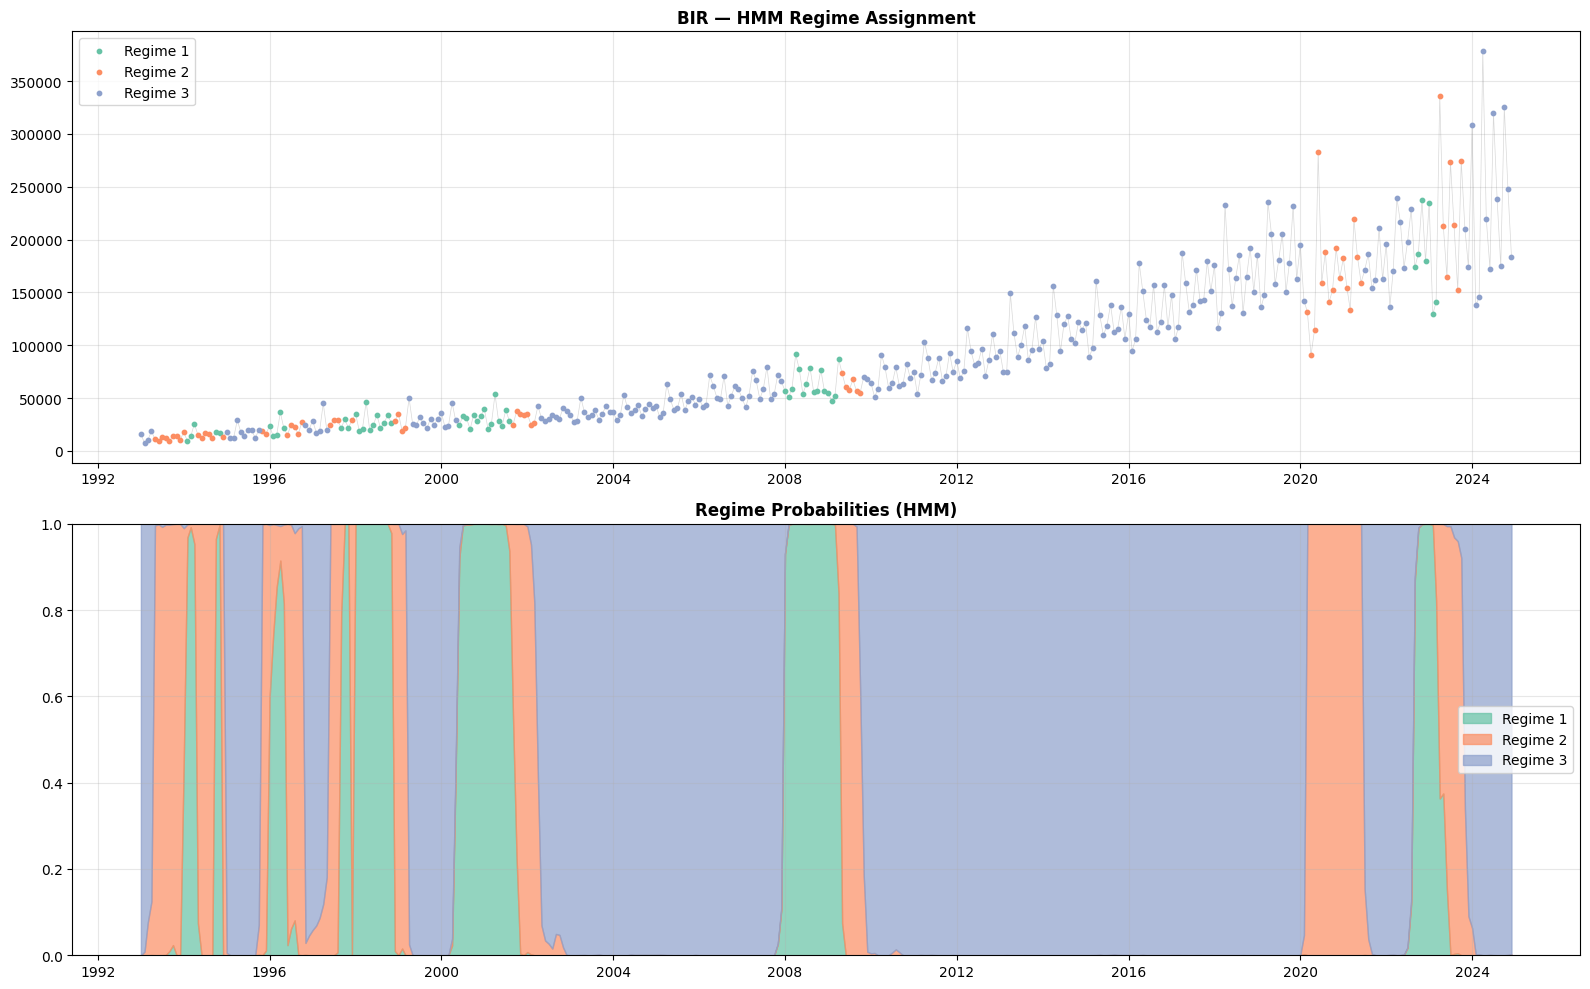


  HMM REGIME CHARACTERISTICS

  Regime 1 (62 months, 16.1%):
    BIR                      : mean=    9.9%, std=  13.6%
    BOC                      : mean=    7.7%, std=  18.1%
    NominalGDP_disagg        : mean=   10.9%, std=   4.0%
    TotalTrade_PHPMN         : mean=   17.2%, std=  23.5%
    USDPHP                   : mean=   15.6%, std=  18.3%
    Inflation                : mean=    3.1%, std=   2.5%

  Regime 2 (66 months, 17.2%):
    BIR                      : mean=   12.9%, std=  30.7%
    BOC                      : mean=   -0.8%, std=  23.5%
    NominalGDP_disagg        : mean=    7.0%, std=   9.3%
    TotalTrade_PHPMN         : mean=    6.8%, std=  26.7%
    USDPHP                   : mean=    2.3%, std=   8.2%
    Inflation                : mean=   -0.4%, std=   3.5%

  Regime 3 (256 months, 66.7%):
    BIR                      : mean=   11.0%, std=   9.8%
    BOC                      : mean=   13.6%, std=  19.0%
    NominalGDP_disagg        : mean=    9.6%, std=   2.5%
   

In [29]:
regime_dates = features_growth.index
regime_colors = ['#66c2a5', '#fc8d62', '#8da0cb']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: BIR colored by regime
ax = axes[0]
y = df.loc[regime_dates, 'BIR']
for j in range(k):
    mask = labels == j
    if mask.any():
        ax.scatter(regime_dates[mask], y.values[mask], c=regime_colors[j],
                   s=10, label=f'Regime {j+1}', zorder=3)
ax.plot(regime_dates, y.values, color='gray', linewidth=0.5, alpha=0.3)
ax.set_title('BIR — HMM Regime Assignment', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom: Regime probabilities
ax2 = axes[1]
bottom = np.zeros(len(regime_dates))
for j in range(k):
    ax2.fill_between(regime_dates, bottom, bottom + probs[:, j],
                     alpha=0.7, color=regime_colors[j], label=f'Regime {j+1}')
    bottom += probs[:, j]
ax2.set_ylim(0, 1)
ax2.set_title('Regime Probabilities (HMM)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Regime characteristics
print(f"\n{'='*60}")
print(f"  HMM REGIME CHARACTERISTICS")
print(f"{'='*60}")
for j in range(k):
    mask = labels == j
    print(f"\n  Regime {j+1} ({mask.sum()} months, {mask.mean():.1%}):")
    for col in features_growth.columns:
        vals = features_growth.loc[mask, col]
        print(f"    {col:25s}: mean={vals.mean():7.1f}%, std={vals.std():6.1f}%")

# Transition matrix
print(f"\n  Transition matrix:")
P = model.transmat_
for i in range(k):
    vals = "  ".join([f"{P[i,j]:.3f}" for j in range(k)])
    print(f"    [{vals}]")